# MOGA-Phonons Experiment Dataframe Explorer

This notebook loads a pickled dataframe produced by `build_experiment_dataframe_updated.py` and provides quick visual diagnostics for a MOGA-Phonons experiment.

Designed for files such as:

```text
dataframes/dataframe000009.pkl
dataframes/dataframe000009.summary.json
```


## 1. Imports and paths

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumes this notebook is run from the repo root.
repo_root = Path.cwd()

experiment_id = "experiment000012"
df_path = repo_root / "dataframes" / "dataframe000012.pkl"
summary_path = repo_root / "dataframes" / "dataframe000012.summary.json"

print("Repo root:", repo_root)
print("Dataframe:", df_path)
print("Summary:", summary_path)


Repo root: /Users/jamunoz/Documents/GitHub/MOGA-Phonons
Dataframe: /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/dataframe000012.pkl
Summary: /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/dataframe000012.summary.json


## 2. Load dataframe and summary

In [3]:
df = pd.read_pickle(df_path)

if summary_path.exists():
    with open(summary_path, "r") as f:
        summary = json.load(f)
else:
    summary = {}

print("Rows:", len(df))
print("Columns:", len(df.columns))
display(pd.DataFrame(summary.items(), columns=["field", "value"]))
display(df.head())


Rows: 63000
Columns: 34


,field,value
0,n_simulations_in_experiment,42
1,n_yaml_tasks,63000
2,n_missing_simulation_dirs,0
3,n_missing_phonon_dirs,0
4,n_simulations_with_no_yaml,0
5,missing_simulation_dirs,[]
6,missing_phonon_dirs,[]
7,simulations_with_no_yaml,[]
8,n_rows,63000
9,n_load_errors,0


,simulation,generation,solution_index,rank,source,timestamp,mass,a_val,system_size,alpha0,...,stable,gamma_frequencies,distances,qpoints,frequencies,frequency_vector,simulation_path,generation_dir,solution_dir,band_yaml_path
0,simulation000546,1,2,0,population,2026-05-21T22:44:42.856738,50.0,2.0,5,8.104749,...,True,"[2.0295737, 2.0295737, 2.0295737]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[2.0295737, 2.0295737, 2.0295737], [2.0302944...","[2.0295737, 2.0295737, 2.0295737, 2.0302944, 2...",simulations/simulation000546,simulations/simulation000546/phonon_generation...,simulations/simulation000546/phonon_generation...,simulations/simulation000546/phonon_generation...
1,simulation000546,1,39,1,population,2026-05-21T22:44:42.856738,50.0,2.0,5,8.528800,...,True,"[3.8691082, 3.8691082, 3.8691082]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[3.8691082, 3.8691082, 3.8691082], [3.8693614...","[3.8691082, 3.8691082, 3.8691082, 3.8693614, 3...",simulations/simulation000546,simulations/simulation000546/phonon_generation...,simulations/simulation000546/phonon_generation...,simulations/simulation000546/phonon_generation...
2,simulation000546,1,47,2,population,2026-05-21T22:44:42.856738,50.0,2.0,5,5.618405,...,False,"[0.16603716, 0.16603716, 0.16603716]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[0.16603716, 0.16603716, 0.16603716], [0.1613...","[0.16603716, 0.16603716, 0.16603716, 0.1613447...",simulations/simulation000546,simulations/simulation000546/phonon_generation...,simulations/simulation000546/phonon_generation...,simulations/simulation000546/phonon_generation...
3,simulation000546,1,51,3,population,2026-05-21T22:44:42.856738,50.0,2.0,5,8.388442,...,False,"[5.709962, 5.709962, 5.709962]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[5.709962, 5.709962, 5.709962], [5.7095637, 5...","[5.709962, 5.709962, 5.709962, 5.7095637, 5.70...",simulations/simulation000546,simulations/simulation000546/phonon_generation...,simulations/simulation000546/phonon_generation...,simulations/simulation000546/phonon_generation...
4,simulation000546,1,30,4,population,2026-05-21T22:44:42.856738,50.0,2.0,5,7.977889,...,True,"[5.007359, 5.007359, 5.007359]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[5.007359, 5.007359, 5.007359], [5.0070667, 5...","[5.007359, 5.007359, 5.007359, 5.0070667, 5.00...",simulations/simulation000546,simulations/simulation000546/phonon_generation...,simulations/simulation000546/phonon_generation...,simulations/simulation000546/phonon_generation...


## 3. Inspect dataframe schema

In [4]:
schema_rows = []
for c in df.columns:
    s = df[c]
    try:
        n_unique = s.nunique(dropna=True)
    except TypeError:
        n_unique = None
    schema_rows.append({
        "column": c,
        "dtype": str(s.dtype),
        "non_null": int(s.notna().sum()),
        "n_unique": n_unique,
    })

schema = pd.DataFrame(schema_rows)
display(schema)


,column,dtype,non_null,n_unique
0,simulation,object,63000,42.0
1,generation,int32,63000,300.0
2,solution_index,int32,63000,100.0
3,rank,int32,63000,5.0
4,source,object,63000,1.0
5,timestamp,object,63000,12600.0
6,mass,float32,63000,6.0
7,a_val,float32,63000,7.0
8,system_size,int32,63000,1.0
9,alpha0,float32,63000,4571.0


## 4. Basic experiment coverage

This checks how many rows are available per simulation and per generation.


count    300.0
mean     210.0
std        0.0
min      210.0
25%      210.0
50%      210.0
75%      210.0
max      210.0
dtype: float64

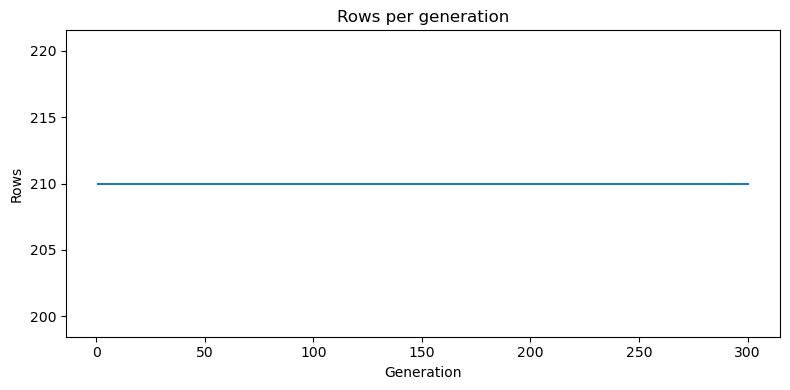

In [5]:
if "simulation_id" in df.columns:
    counts_by_sim = df.groupby("simulation_id").size().sort_index()
    display(counts_by_sim.describe())
    display(counts_by_sim.head())

    plt.figure(figsize=(10, 4))
    counts_by_sim.plot(kind="bar")
    plt.ylabel("Rows")
    plt.xlabel("Simulation")
    plt.title("Rows per simulation")
    plt.tight_layout()
    plt.show()

if "generation" in df.columns:
    counts_by_gen = df.groupby("generation").size().sort_index()
    display(counts_by_gen.describe())

    plt.figure(figsize=(8, 4))
    counts_by_gen.plot()
    plt.ylabel("Rows")
    plt.xlabel("Generation")
    plt.title("Rows per generation")
    plt.tight_layout()
    plt.show()


## 5. Stability overview

The builder adds `min_frequency`, `num_imaginary`, and `is_stable` when possible. These are useful first-pass metrics.


,min_frequency,max_frequency,num_imaginary
count,63000.000000,63000.000000,63000.000000
mean,-0.134086,6.767661,77.066857
std,1.131878,1.292693,127.632250
min,-7.398036,2.473369,0.000000
25%,-0.529571,5.880392,0.000000
50%,-0.053398,6.710362,17.000000
75%,0.393196,7.574802,104.000000
max,5.104550,11.771827,1435.000000


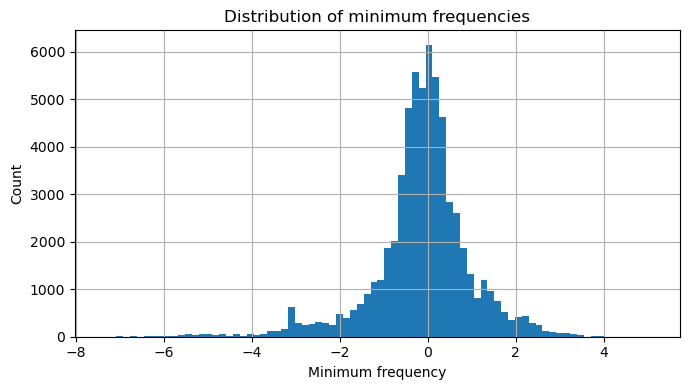

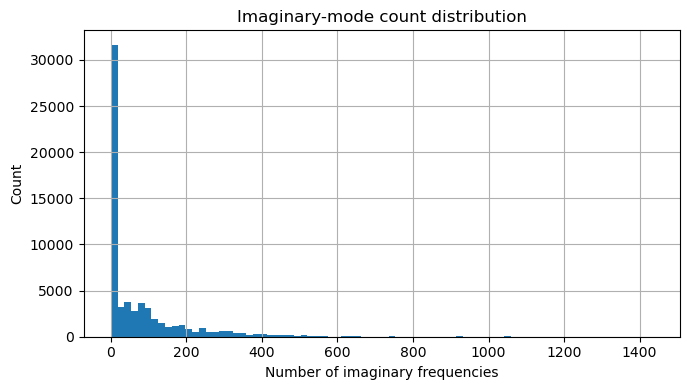

In [6]:
stability_cols = [c for c in ["min_frequency", "max_frequency", "num_imaginary", "is_stable"] if c in df.columns]
display(df[stability_cols].describe(include="all") if stability_cols else "No stability columns found.")

if "is_stable" in df.columns:
    stable_counts = df["is_stable"].value_counts(dropna=False)
    display(stable_counts)
    plt.figure(figsize=(5, 4))
    stable_counts.plot(kind="bar")
    plt.ylabel("Count")
    plt.title("Stable vs unstable candidates")
    plt.tight_layout()
    plt.show()

if "min_frequency" in df.columns:
    plt.figure(figsize=(7, 4))
    df["min_frequency"].dropna().hist(bins=80)
    plt.xlabel("Minimum frequency")
    plt.ylabel("Count")
    plt.title("Distribution of minimum frequencies")
    plt.tight_layout()
    plt.show()

if "num_imaginary" in df.columns:
    plt.figure(figsize=(7, 4))
    df["num_imaginary"].dropna().hist(bins=80)
    plt.xlabel("Number of imaginary frequencies")
    plt.ylabel("Count")
    plt.title("Imaginary-mode count distribution")
    plt.tight_layout()
    plt.show()


## 6. Fitness distributions

,fitness1,fitness2,fitness3,fitness_norm
count,63000.000000,63000.000000,63000.000000,63000.000000
mean,0.938753,0.852281,0.695716,1.490616
std,0.226711,0.207914,0.231861,0.134562
min,0.001550,0.056219,0.161107,1.015850
25%,1.000000,0.807161,0.510329,1.413376
50%,1.000000,0.948706,0.753084,1.499311
75%,1.000000,0.989524,0.905562,1.592520
max,1.000000,0.999998,0.993057,1.718651


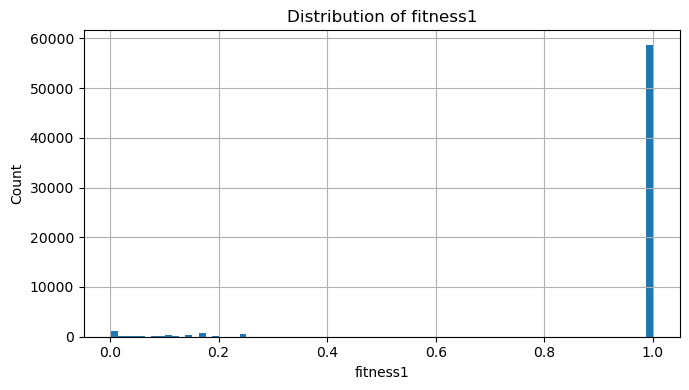

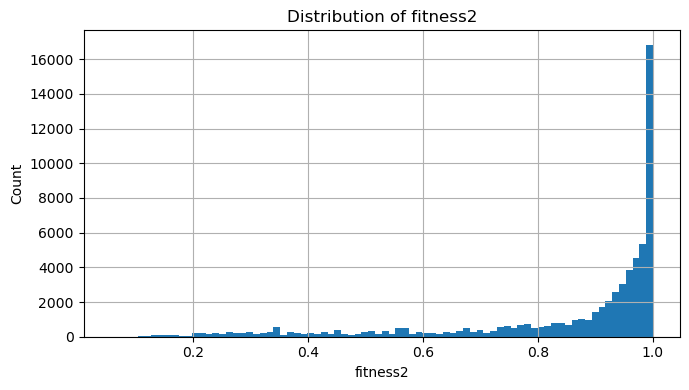

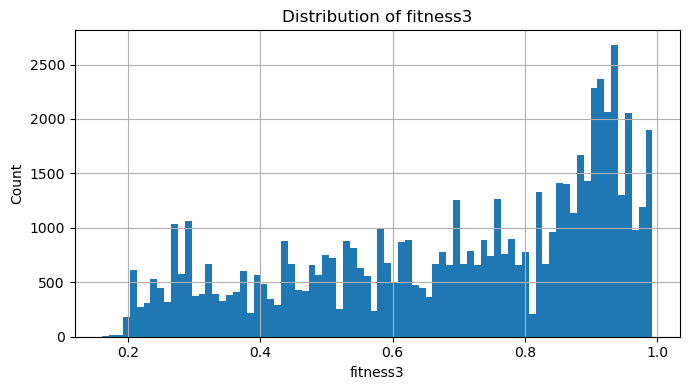

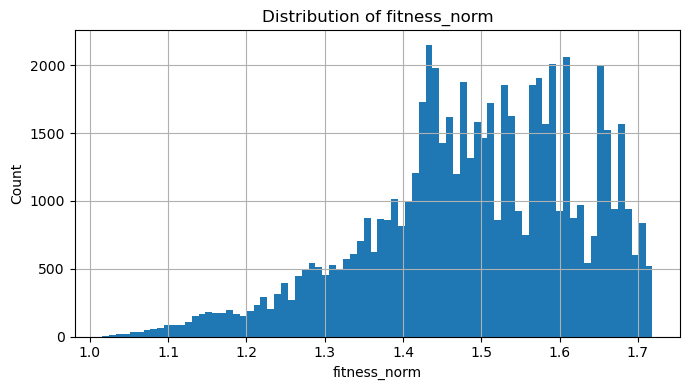

In [7]:
fitness_cols = [c for c in ["fitness1", "fitness2", "fitness3", "fitness_norm"] if c in df.columns]
display(df[fitness_cols].describe() if fitness_cols else "No fitness columns found.")

for col in fitness_cols:
    plt.figure(figsize=(7, 4))
    df[col].dropna().hist(bins=80)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()


## 7. Fitness evolution by generation

This shows whether the top-k candidates improve across generations.


,mean,max,min,std,count
generation,,,,,
1,1.138170,1.596608,1.019687,0.099095,210
2,1.190543,1.596608,1.015850,0.108554,210
3,1.223540,1.596608,1.051186,0.109502,210
4,1.249077,1.596608,1.028720,0.104996,210
5,1.262639,1.596608,1.036417,0.103840,210


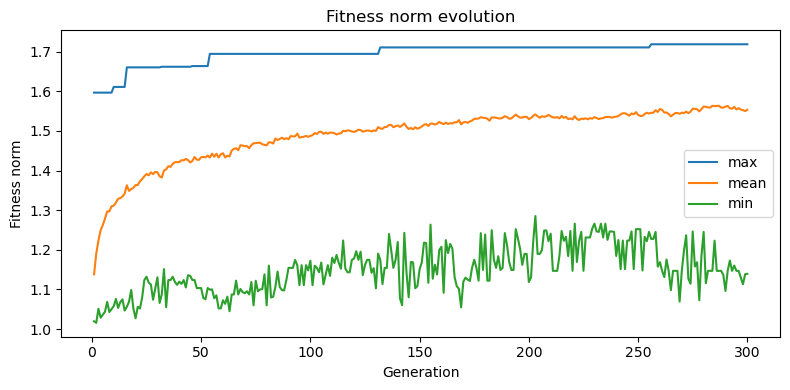

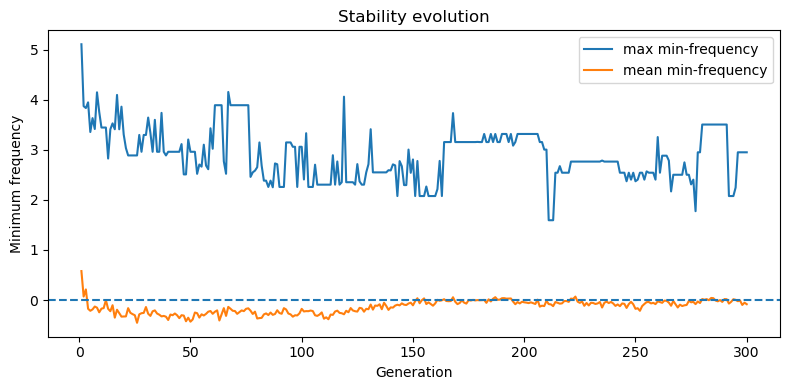

In [8]:
if "generation" in df.columns and "fitness_norm" in df.columns:
    gen_stats = df.groupby("generation")["fitness_norm"].agg(["mean", "max", "min", "std", "count"])
    display(gen_stats.head())

    plt.figure(figsize=(8, 4))
    gen_stats["max"].plot(label="max")
    gen_stats["mean"].plot(label="mean")
    gen_stats["min"].plot(label="min")
    plt.xlabel("Generation")
    plt.ylabel("Fitness norm")
    plt.title("Fitness norm evolution")
    plt.legend()
    plt.tight_layout()
    plt.show()

if "generation" in df.columns and "min_frequency" in df.columns:
    gen_minfreq = df.groupby("generation")["min_frequency"].agg(["mean", "max", "min"])
    plt.figure(figsize=(8, 4))
    gen_minfreq["max"].plot(label="max min-frequency")
    gen_minfreq["mean"].plot(label="mean min-frequency")
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Generation")
    plt.ylabel("Minimum frequency")
    plt.title("Stability evolution")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 8. Parameter sweep maps

These plots summarize behavior over lattice parameter and mass, if `a_val` and `mass` or `atomic_masses` are available.


a_val,2.0,2.2,2.4,2.6,2.8,3.0,3.2
mass,,,,,,,
50.0,1.653074,1.611072,1.613158,1.706269,1.639122,1.648584,1.668559
60.0,1.680077,1.658604,1.658825,1.702255,1.675989,1.689239,1.667792
70.0,1.691599,1.669039,1.703965,1.685620,1.710680,1.543807,1.653094
80.0,1.684946,1.653653,1.637270,1.683871,1.646507,1.590870,1.659509
90.0,1.654603,1.666191,1.691782,1.674490,1.718651,1.613811,1.691322
100.0,1.682892,1.694391,1.709424,1.675714,1.703977,1.703115,1.611407


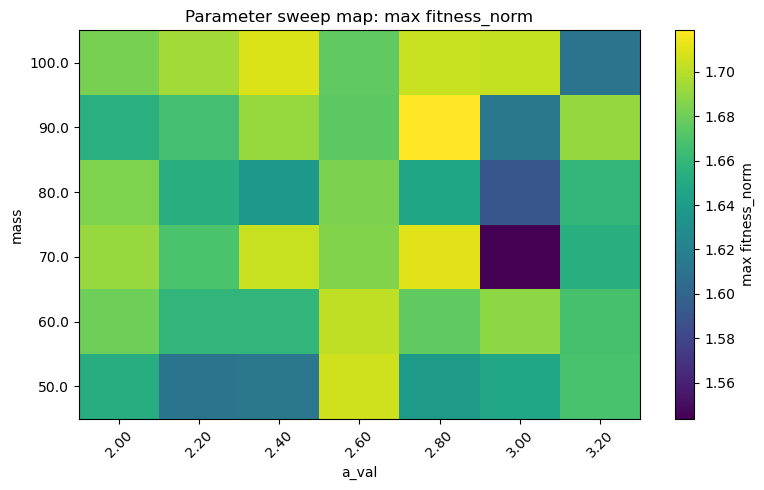

In [9]:
df_plot = df.copy()

if "mass" not in df_plot.columns and "atomic_masses" in df_plot.columns:
    def first_mass(x):
        if isinstance(x, (list, tuple, np.ndarray)):
            return float(x[0])
        return float(x)
    df_plot["mass"] = df_plot["atomic_masses"].map(first_mass)

metric = "fitness_norm" if "fitness_norm" in df_plot.columns else None
if metric and "a_val" in df_plot.columns and "mass" in df_plot.columns:
    pivot = df_plot.groupby(["mass", "a_val"])[metric].max().unstack("a_val")
    display(pivot)

    plt.figure(figsize=(8, 5))
    plt.imshow(pivot.values, aspect="auto", origin="lower")
    plt.colorbar(label=f"max {metric}")
    plt.xticks(range(len(pivot.columns)), [f"{x:.2f}" for x in pivot.columns], rotation=45)
    plt.yticks(range(len(pivot.index)), [f"{x:.1f}" for x in pivot.index])
    plt.xlabel("a_val")
    plt.ylabel("mass")
    plt.title(f"Parameter sweep map: max {metric}")
    plt.tight_layout()
    plt.show()

if "is_stable" in df_plot.columns and "a_val" in df_plot.columns and "mass" in df_plot.columns:
    stable_fraction = df_plot.groupby(["mass", "a_val"])["is_stable"].mean().unstack("a_val")
    display(stable_fraction)

    plt.figure(figsize=(8, 5))
    plt.imshow(stable_fraction.values, aspect="auto", origin="lower", vmin=0, vmax=1)
    plt.colorbar(label="stable fraction")
    plt.xticks(range(len(stable_fraction.columns)), [f"{x:.2f}" for x in stable_fraction.columns], rotation=45)
    plt.yticks(range(len(stable_fraction.index)), [f"{x:.1f}" for x in stable_fraction.index])
    plt.xlabel("a_val")
    plt.ylabel("mass")
    plt.title("Stable-candidate fraction across parameter sweep")
    plt.tight_layout()
    plt.show()


## 9. Force-constant relationships

Scatter plots of the reduced BvK parameters and their relation to fitness/stability.


,alpha0,alpha1,beta1,alpha2,beta2
count,63000.000000,63000.000000,63000.000000,63000.000000,63000.000000
mean,7.241735,-0.510420,-0.009611,-0.552636,-0.478248
std,1.843442,0.283368,0.577826,0.692945,0.590415
min,1.075120,-1.649138,-1.986767,-1.999599,-1.991966
25%,6.087350,-0.706965,-0.410313,-1.139039,-0.909490
50%,7.634163,-0.535833,0.029422,-0.375674,-0.327206
75%,8.671979,-0.290080,0.411819,-0.021037,-0.021026
max,9.999774,0.822809,1.998299,1.997899,1.997978


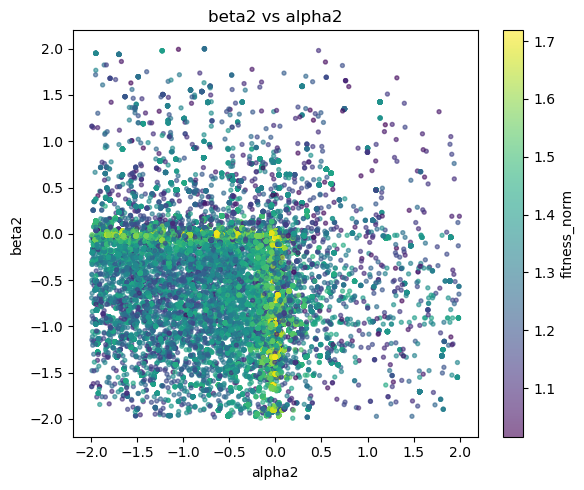

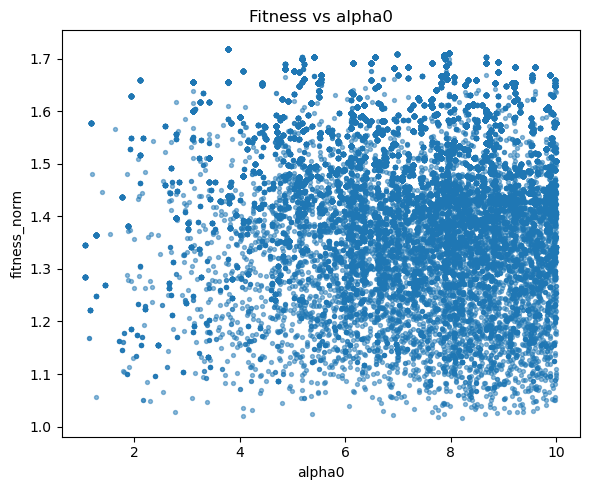

In [10]:
fc_cols = [c for c in ["alpha0", "alpha1", "beta1", "alpha2", "beta2"] if c in df.columns]
display(df[fc_cols].describe() if fc_cols else "No force-constant columns found.")

if len(fc_cols) >= 2:
    color_col = "fitness_norm" if "fitness_norm" in df.columns else None
    xcol, ycol = "alpha2", "beta2"
    if xcol in df.columns and ycol in df.columns:
        plt.figure(figsize=(6, 5))
        if color_col:
            sc = plt.scatter(df[xcol], df[ycol], c=df[color_col], s=8, alpha=0.6)
            plt.colorbar(sc, label=color_col)
        else:
            plt.scatter(df[xcol], df[ycol], s=8, alpha=0.6)
        plt.xlabel(xcol)
        plt.ylabel(ycol)
        plt.title(f"{ycol} vs {xcol}")
        plt.tight_layout()
        plt.show()

if "alpha0" in df.columns and "fitness_norm" in df.columns:
    plt.figure(figsize=(6, 5))
    plt.scatter(df["alpha0"], df["fitness_norm"], s=8, alpha=0.5)
    plt.xlabel("alpha0")
    plt.ylabel("fitness_norm")
    plt.title("Fitness vs alpha0")
    plt.tight_layout()
    plt.show()


,alpha0,alpha1,beta1,alpha2,beta2
count,63000.000000,63000.000000,63000.000000,63000.000000,63000.000000
mean,7.241735,-0.510420,-0.009611,-0.552636,-0.478248
std,1.843442,0.283368,0.577826,0.692945,0.590415
min,1.075120,-1.649138,-1.986767,-1.999599,-1.991966
25%,6.087350,-0.706965,-0.410313,-1.139039,-0.909490
50%,7.634163,-0.535833,0.029422,-0.375674,-0.327206
75%,8.671979,-0.290080,0.411819,-0.021037,-0.021026
max,9.999774,0.822809,1.998299,1.997899,1.997978


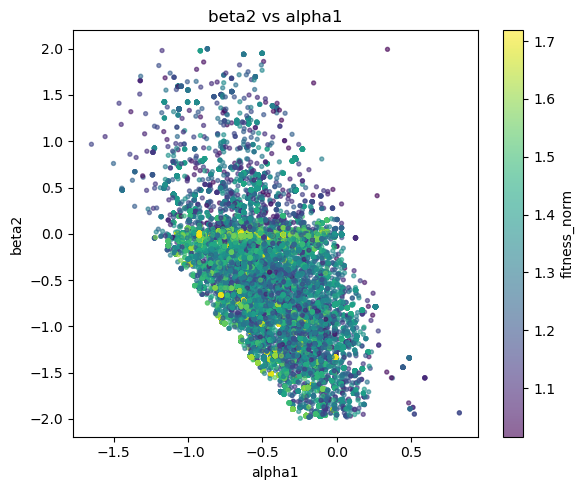

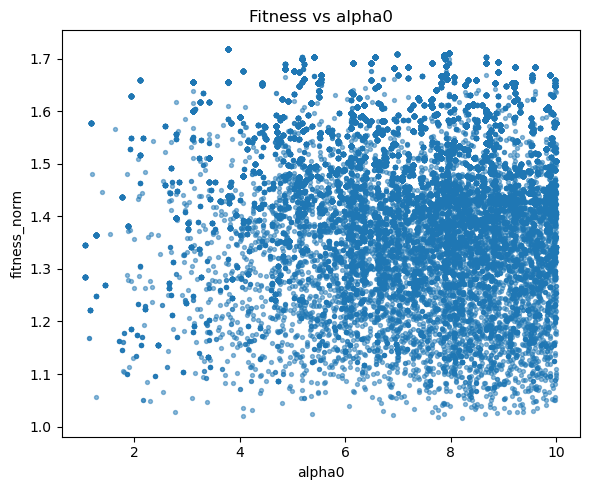

In [11]:
fc_cols = [c for c in ["alpha0", "alpha1", "beta1", "alpha2", "beta2"] if c in df.columns]
display(df[fc_cols].describe() if fc_cols else "No force-constant columns found.")

if len(fc_cols) >= 2:
    color_col = "fitness_norm" if "fitness_norm" in df.columns else None
    xcol, ycol = "alpha1", "beta2"
    if xcol in df.columns and ycol in df.columns:
        plt.figure(figsize=(6, 5))
        if color_col:
            sc = plt.scatter(df[xcol], df[ycol], c=df[color_col], s=8, alpha=0.6)
            plt.colorbar(sc, label=color_col)
        else:
            plt.scatter(df[xcol], df[ycol], s=8, alpha=0.6)
        plt.xlabel(xcol)
        plt.ylabel(ycol)
        plt.title(f"{ycol} vs {xcol}")
        plt.tight_layout()
        plt.show()

if "alpha0" in df.columns and "fitness_norm" in df.columns:
    plt.figure(figsize=(6, 5))
    plt.scatter(df["alpha0"], df["fitness_norm"], s=8, alpha=0.5)
    plt.xlabel("alpha0")
    plt.ylabel("fitness_norm")
    plt.title("Fitness vs alpha0")
    plt.tight_layout()
    plt.show()


,alpha0,alpha1,beta1,alpha2,beta2
count,63000.000000,63000.000000,63000.000000,63000.000000,63000.000000
mean,7.241735,-0.510420,-0.009611,-0.552636,-0.478248
std,1.843442,0.283368,0.577826,0.692945,0.590415
min,1.075120,-1.649138,-1.986767,-1.999599,-1.991966
25%,6.087350,-0.706965,-0.410313,-1.139039,-0.909490
50%,7.634163,-0.535833,0.029422,-0.375674,-0.327206
75%,8.671979,-0.290080,0.411819,-0.021037,-0.021026
max,9.999774,0.822809,1.998299,1.997899,1.997978


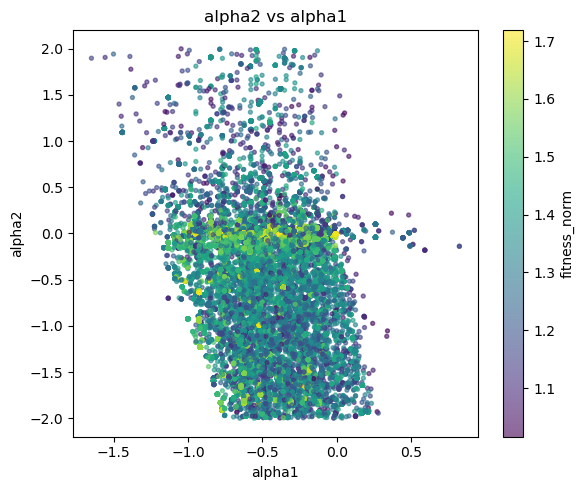

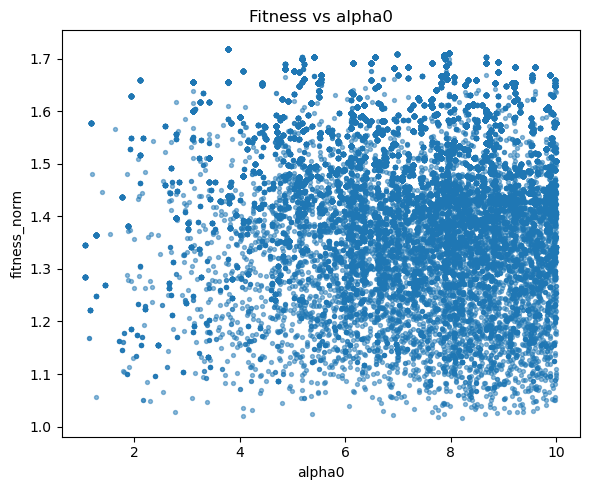

In [12]:
fc_cols = [c for c in ["alpha0", "alpha1", "beta1", "alpha2", "beta2"] if c in df.columns]
display(df[fc_cols].describe() if fc_cols else "No force-constant columns found.")

if len(fc_cols) >= 2:
    color_col = "fitness_norm" if "fitness_norm" in df.columns else None
    xcol, ycol = "alpha1", "alpha2"
    if xcol in df.columns and ycol in df.columns:
        plt.figure(figsize=(6, 5))
        if color_col:
            sc = plt.scatter(df[xcol], df[ycol], c=df[color_col], s=8, alpha=0.6)
            plt.colorbar(sc, label=color_col)
        else:
            plt.scatter(df[xcol], df[ycol], s=8, alpha=0.6)
        plt.xlabel(xcol)
        plt.ylabel(ycol)
        plt.title(f"{ycol} vs {xcol}")
        plt.tight_layout()
        plt.show()

if "alpha0" in df.columns and "fitness_norm" in df.columns:
    plt.figure(figsize=(6, 5))
    plt.scatter(df["alpha0"], df["fitness_norm"], s=8, alpha=0.5)
    plt.xlabel("alpha0")
    plt.ylabel("fitness_norm")
    plt.title("Fitness vs alpha0")
    plt.tight_layout()
    plt.show()

## 10. Top candidates

This table lists the highest-ranking candidates according to `fitness_norm`, with stable candidates prioritized if available.


In [13]:
preferred_cols = [
    "simulation_id", "generation", "solution_index", "rank",
    "a_val", "mass",
    "alpha0", "alpha1", "beta1", "alpha2", "beta2",
    "fitness1", "fitness2", "fitness3", "fitness_norm",
    "min_frequency", "num_imaginary", "is_stable",
    "yaml_path", "plot_path"
]
cols = [c for c in preferred_cols if c in df_plot.columns]

sort_cols = []
ascending = []
if "is_stable" in df_plot.columns:
    sort_cols.append("is_stable")
    ascending.append(False)
if "fitness_norm" in df_plot.columns:
    sort_cols.append("fitness_norm")
    ascending.append(False)
elif "min_frequency" in df_plot.columns:
    sort_cols.append("min_frequency")
    ascending.append(False)

top = df_plot.sort_values(sort_cols, ascending=ascending).head(25) if sort_cols else df_plot.head(25)
display(top[cols])


,generation,solution_index,rank,a_val,mass,alpha0,alpha1,beta1,alpha2,beta2,fitness1,fitness2,fitness3,fitness_norm,min_frequency,num_imaginary
49432,287,6,2,2.8,90.0,3.784218,-0.450043,0.309882,-0.008116,-0.045965,1.0,0.984042,0.992684,1.718651,-0.209872,79
49360,273,2,0,2.8,90.0,3.784218,-0.450043,0.372092,-0.008116,-0.045965,1.0,0.984042,0.992684,1.718651,-0.231569,115
49471,295,3,1,2.8,90.0,3.784218,-0.450043,0.372092,-0.008116,-0.045965,1.0,0.984042,0.992684,1.718651,-0.231569,115
49325,266,2,0,2.8,90.0,3.784218,-0.450043,0.372092,-0.008116,-0.045965,1.0,0.984042,0.992684,1.718651,-0.231569,115
49472,295,7,2,2.8,90.0,3.784218,-0.450043,0.309882,-0.008116,-0.045965,1.0,0.984042,0.992684,1.718651,-0.209872,79
49402,281,6,2,2.8,90.0,3.784218,-0.450043,0.309882,-0.008116,-0.045965,1.0,0.984042,0.992684,1.718651,-0.209872,79
49473,295,9,3,2.8,90.0,3.784218,-0.450043,0.372092,-0.008116,-0.045965,1.0,0.984042,0.992684,1.718651,-0.231569,115
49311,263,3,1,2.8,90.0,3.784218,-0.450043,0.372092,-0.008116,-0.045965,1.0,0.984042,0.992684,1.718651,-0.231569,115
49475,296,2,0,2.8,90.0,3.784218,-0.450043,0.372092,-0.008116,-0.045965,1.0,0.984042,0.992684,1.718651,-0.231569,115
49361,273,3,1,2.8,90.0,3.784218,-0.450043,0.372092,-0.008116,-0.045965,1.0,0.984042,0.992684,1.718651,-0.231569,115


## 11. Save filtered subsets

Useful for making small curated datasets for plotting, manuscript figures, or Zenodo releases.


In [14]:
# Best row by fitness_norm for each (a_val, mass)
idx = df.groupby(["a_val", "mass"])["fitness_norm"].idxmax()

best_df = (
    df.loc[idx]
    .sort_values(["a_val", "mass"])
    .reset_index(drop=True)
)

best_df.head()

,simulation,generation,solution_index,rank,source,timestamp,mass,a_val,system_size,alpha0,...,stable,gamma_frequencies,distances,qpoints,frequencies,frequency_vector,simulation_path,generation_dir,solution_dir,band_yaml_path
0,simulation000546,193,59,0,population,2026-05-21T22:54:47.159683,50.0,2.0,5,9.213300,...,True,"[0.37701872, 0.37701872, 0.37701872]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[0.37701872, 0.37701872, 0.37701872], [0.3794...","[0.37701872, 0.37701872, 0.37701872, 0.3794110...",simulations/simulation000546,simulations/simulation000546/phonon_generation...,simulations/simulation000546/phonon_generation...,simulations/simulation000546/phonon_generation...
1,simulation000553,289,15,0,population,2026-05-22T00:51:04.655845,60.0,2.0,5,5.210220,...,False,"[-0.3313867, -0.3313867, -0.3313867]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-0.3313867, -0.3313867, -0.3313867], [-0.328...","[-0.3313867, -0.3313867, -0.3313867, -0.328480...",simulations/simulation000553,simulations/simulation000553/phonon_generation...,simulations/simulation000553/phonon_generation...,simulations/simulation000553/phonon_generation...
2,simulation000560,267,53,0,population,2026-05-22T02:40:30.909488,70.0,2.0,5,7.647476,...,False,"[-0.12422609, -0.12422609, -0.12422609]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-0.12422609, -0.12422609, -0.12422609], [-0....","[-0.12422609, -0.12422609, -0.12422609, -0.110...",simulations/simulation000560,simulations/simulation000560/phonon_generation...,simulations/simulation000560/phonon_generation...,simulations/simulation000560/phonon_generation...
3,simulation000567,107,56,0,population,2026-05-22T04:22:35.874021,80.0,2.0,5,9.210196,...,True,"[0.27190262, 0.27190262, 0.27190262]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[0.27190262, 0.27190262, 0.27190262], [0.2774...","[0.27190262, 0.27190262, 0.27190262, 0.2774843...",simulations/simulation000567,simulations/simulation000567/phonon_generation...,simulations/simulation000567/phonon_generation...,simulations/simulation000567/phonon_generation...
4,simulation000574,137,98,0,population,2026-05-22T06:14:33.086847,90.0,2.0,5,3.119083,...,True,"[0.1356889, 0.1356889, 0.1356889]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[0.1356889, 0.1356889, 0.1356889], [0.1391693...","[0.1356889, 0.1356889, 0.1356889, 0.13916935, ...",simulations/simulation000574,simulations/simulation000574/phonon_generation...,simulations/simulation000574/phonon_generation...,simulations/simulation000574/phonon_generation...


In [15]:
best_df[
    [
        "simulation",
        "generation",
        "a_val",
        "mass",
        "alpha0",
        "alpha1",
        "beta1",
        "alpha2",
        "beta2",
        "fitness_norm",
        "fitness1",
        "fitness2",
        "fitness3",
        "min_frequency",
        "num_imaginary",
    ]
]

,simulation,generation,a_val,mass,alpha0,alpha1,beta1,alpha2,beta2,fitness_norm,fitness1,fitness2,fitness3,min_frequency,num_imaginary
0,simulation000546,193,2.0,50.0,9.213300,-0.388025,-0.768837,0.012908,-1.526455,1.653074,1.0,0.971731,0.887915,0.377019,0
1,simulation000553,289,2.0,60.0,5.210220,-0.463025,-0.470277,-0.014073,-0.376217,1.680077,1.0,0.973717,0.935166,-0.331387,80
2,simulation000560,267,2.0,70.0,7.647476,-0.947562,0.141867,-0.002955,-0.016383,1.691599,1.0,0.995559,0.932937,-0.124226,29
3,simulation000567,107,2.0,80.0,9.210196,-1.022778,0.355660,-0.513343,0.005730,1.684946,1.0,0.976363,0.941147,0.271903,0
4,simulation000574,137,2.0,90.0,3.119083,-0.355972,-0.295021,-0.000974,-0.065654,1.654603,1.0,0.993300,0.866640,0.135689,0
5,simulation000581,131,2.0,100.0,6.927640,-0.846515,0.066824,0.008725,-0.038340,1.682892,1.0,0.980771,0.932852,0.218755,0
6,simulation000547,209,2.2,50.0,7.289214,-0.534898,0.019721,-0.053021,-0.751533,1.611072,1.0,0.907322,0.878818,-0.706618,112
7,simulation000554,188,2.2,60.0,8.474932,-0.284321,0.742167,0.027653,-1.549686,1.658604,1.0,0.946142,0.925085,0.481470,0
8,simulation000561,253,2.2,70.0,7.002044,-0.249124,-0.465527,0.034534,-1.252105,1.669039,1.0,0.934841,0.954863,0.493308,0
9,simulation000568,217,2.2,80.0,4.427212,-0.182952,0.288907,-1.480980,-0.019560,1.653653,1.0,0.928847,0.933708,-0.483717,144


In [16]:
df_valid = df.dropna(subset=["fitness_norm"])

idx = df_valid.groupby(["a_val", "mass"])["fitness_norm"].idxmax()

best_df = (
    df_valid.loc[idx]
    .sort_values(["a_val", "mass"])
    .reset_index(drop=True)
)

In [17]:
from pathlib import Path

REPO_ROOT = Path.cwd()

best_df = best_df.copy()

best_df["dispersion_path"] = best_df["generation_dir"].apply(
    lambda p: REPO_ROOT / p / "dispersion.png"
)

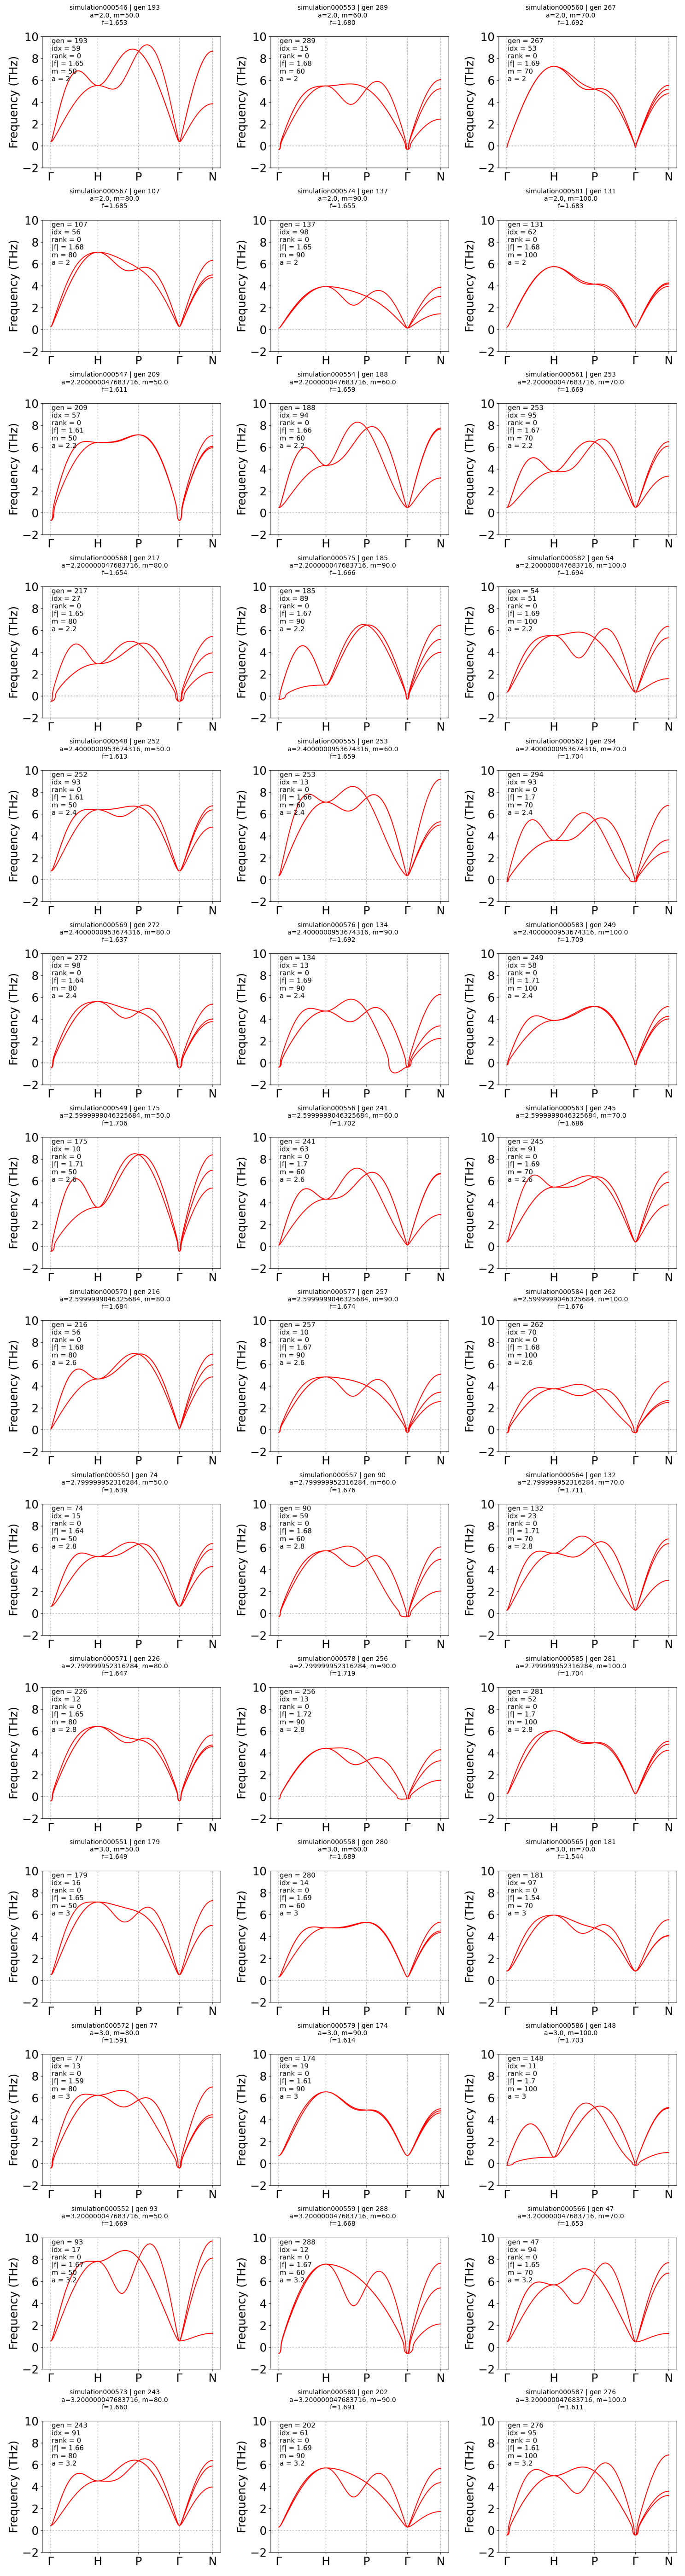

In [18]:
import math
from pathlib import Path

import matplotlib.pyplot as plt


def build_dispersion_path(row):
    """
    Build dispersion.png path from dataframe row.
    """

    generation_dir = f"generation_{int(row['generation']):06d}"

    # top-k/all selections
    if "solution_index" in row.index and "rank" in row.index:
        solution_dir = (
            f"solution_{int(row['solution_index']):06d}"
            f"_rank_{int(row['rank']):03d}"
        )

        return (
            Path(row["simulation_path"])
            / "phonon_generations"
            / generation_dir
            / solution_dir
            / "dispersion.png"
        )

    # fallback for selection="best"
    return (
        Path(row["simulation_path"])
        / "phonon_generations"
        / generation_dir
        / "dispersion.png"
    )


n = len(best_df)

ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5*ncols, 4*nrows),
)

axes = axes.ravel()

for ax, (_, row) in zip(axes, best_df.iterrows()):

    dispersion_path = build_dispersion_path(row)

    if not dispersion_path.is_file():
        ax.text(
            0.5,
            0.5,
            f"Missing:\n{dispersion_path.name}",
            ha="center",
            va="center",
        )
        ax.axis("off")
        continue

    img = plt.imread(dispersion_path)

    ax.imshow(img)
    ax.axis("off")

    ax.set_title(
        f"{row['simulation']} | gen {row['generation']}\n"
        f"a={row['a_val']}, m={row['mass']}\n"
        f"f={row['fitness_norm']:.3f}",
        fontsize=10,
    )

for ax in axes[len(best_df):]:
    ax.axis("off")

plt.tight_layout()

plt.show()

In [19]:
output_dir = repo_root / "dataframes" / "subsets"
output_dir.mkdir(parents=True, exist_ok=True)

if "is_stable" in df_plot.columns:
    stable_df = df_plot[df_plot["is_stable"] == True].copy()
    stable_path = output_dir / f"{experiment_id}_stable_candidates.pkl"
    stable_df.to_pickle(stable_path)
    print("Saved stable candidates:", stable_path, "rows =", len(stable_df))

if "fitness_norm" in df_plot.columns:
    top_path = output_dir / f"{experiment_id}_top100_by_fitness_norm.pkl"
    df_plot.sort_values("fitness_norm", ascending=False).head(100).to_pickle(top_path)
    print("Saved top 100:", top_path)


Saved top 100: /Users/jamunoz/Documents/GitHub/MOGA-Phonons/dataframes/subsets/experiment000012_top100_by_fitness_norm.pkl


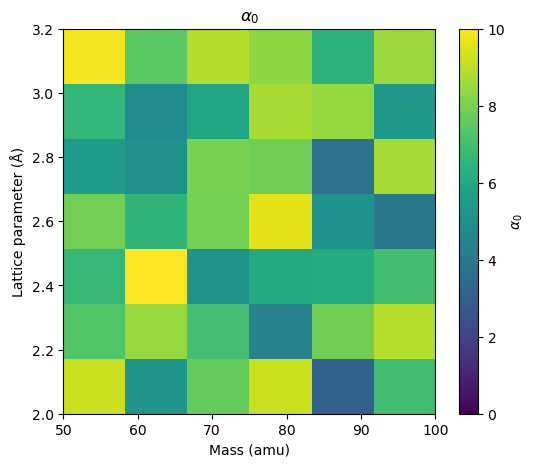

In [20]:
import matplotlib.pyplot as plt

pivot = best_df.pivot(
    index="a_val",
    columns="mass",
    values="alpha0",
)

plt.figure(figsize=(6,5))

plt.imshow(
    pivot,
    origin="lower",
    aspect="auto",
    extent=[
        pivot.columns.min(),
        pivot.columns.max(),
        pivot.index.min(),
        pivot.index.max(),
    ],
    vmin=0.0,
    vmax=10.0,
)

plt.xlabel("Mass (amu)")
plt.ylabel("Lattice parameter (Å)")
plt.title(r"$\alpha_0$")

plt.colorbar(label=r"$\alpha_0$")

plt.show()

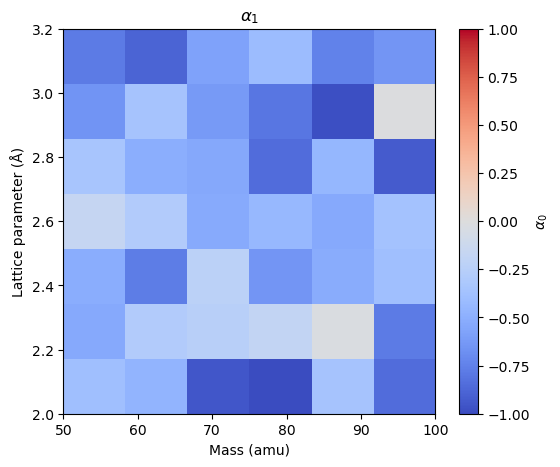

In [21]:
import matplotlib.pyplot as plt

pivot = best_df.pivot(
    index="a_val",
    columns="mass",
    values="alpha1",
)

plt.figure(figsize=(6,5))

plt.imshow(
    pivot,
    origin="lower",
    aspect="auto",
    extent=[
        pivot.columns.min(),
        pivot.columns.max(),
        pivot.index.min(),
        pivot.index.max(),
    ],
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

plt.xlabel("Mass (amu)")
plt.ylabel("Lattice parameter (Å)")
plt.title(r"$\alpha_1$")


plt.colorbar(label=r"$\alpha_0$")

plt.show()

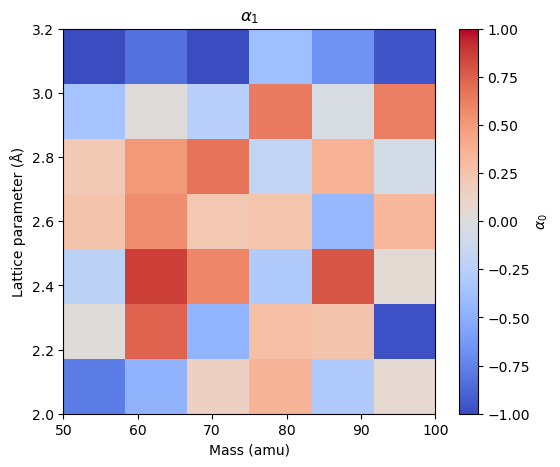

In [22]:
import matplotlib.pyplot as plt

pivot = best_df.pivot(
    index="a_val",
    columns="mass",
    values="beta1",
)

plt.figure(figsize=(6,5))

plt.imshow(
    pivot,
    origin="lower",
    aspect="auto",
    extent=[
        pivot.columns.min(),
        pivot.columns.max(),
        pivot.index.min(),
        pivot.index.max(),
    ],
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

plt.xlabel("Mass (amu)")
plt.ylabel("Lattice parameter (Å)")
plt.title(r"$\alpha_1$")


plt.colorbar(label=r"$\alpha_0$")

plt.show()

In [23]:
cols = [
    "mass",
    "a_val",
    "alpha0",
    "alpha1",
    "beta1",
    "alpha2",
    "beta2",
    "fitness_norm",
]

best_df[cols].corr()

,mass,a_val,alpha0,alpha1,beta1,alpha2,beta2,fitness_norm
mass,1.000000e+00,-1.118636e-15,-0.137073,-0.102017,0.028499,-0.109997,0.237810,0.201738
a_val,-1.118636e-15,1.000000e+00,0.096181,-0.156264,-0.244798,-0.023956,0.080974,-0.176861
alpha0,-1.370732e-01,9.618112e-02,1.000000,-0.439405,-0.185745,-0.052274,-0.323679,-0.101812
alpha1,-1.020174e-01,-1.562640e-01,-0.439405,1.000000,0.287833,0.094174,-0.588925,0.204348
beta1,2.849922e-02,-2.447981e-01,-0.185745,0.287833,1.000000,-0.253987,0.008741,0.233486
alpha2,-1.099968e-01,-2.395588e-02,-0.052274,0.094174,-0.253987,1.000000,-0.527135,0.141047
beta2,2.378105e-01,8.097378e-02,-0.323679,-0.588925,0.008741,-0.527135,1.000000,-0.178890
fitness_norm,2.017376e-01,-1.768612e-01,-0.101812,0.204348,0.233486,0.141047,-0.178890,1.000000


<Axes: >

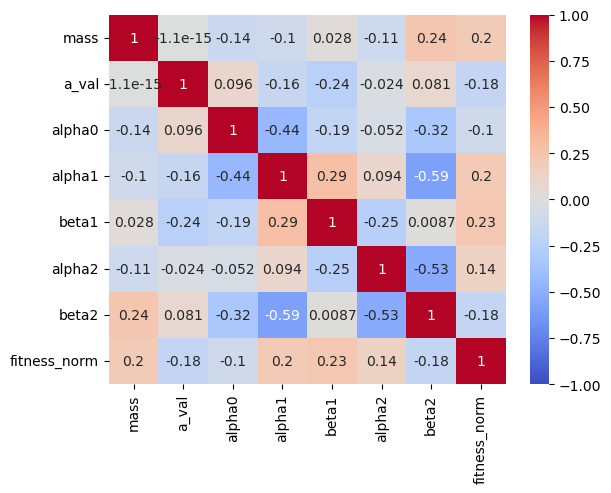

In [24]:
import seaborn as sns

sns.heatmap(best_df[cols].corr(), annot=True, vmin=-1, vmax=1, cmap="coolwarm")

In [25]:
X = best_df[
    ["alpha0","alpha1","beta1","alpha2","beta2"]
].values

In [26]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

fc_cols = [
    "alpha0",
    "alpha1",
    "beta1",
    "alpha2",
    "beta2",
]

X = best_df[fc_cols].values

In [27]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [28]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [29]:
print(pca.explained_variance_ratio_)

[0.36888662 0.31586373]


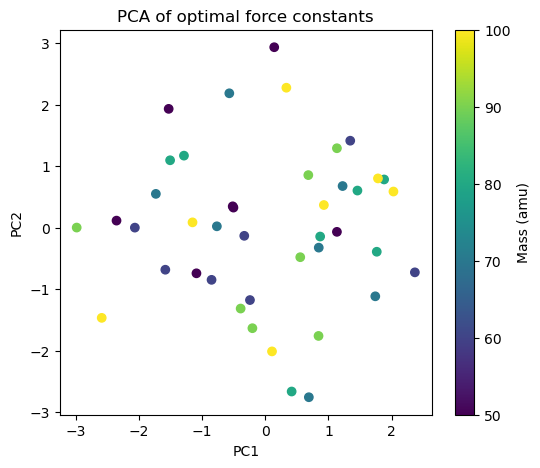

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sc = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=best_df["mass"],
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(sc, label="Mass (amu)")

plt.title("PCA of optimal force constants")

plt.show()

In [31]:
c=best_df["a_val"]

In [32]:
c=best_df["fitness_norm"]

In [33]:
loadings = pd.DataFrame(
    pca.components_,
    columns=fc_cols,
    index=["PC1", "PC2"],
)

loadings

,alpha0,alpha1,beta1,alpha2,beta2
PC1,0.099003,-0.586509,-0.077166,-0.457935,0.656161
PC2,0.589412,-0.397552,-0.547261,0.357758,-0.258963


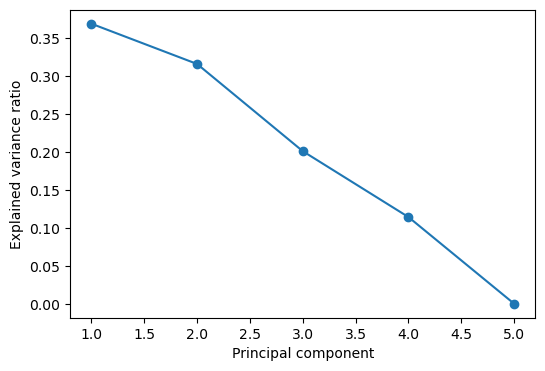

In [34]:
pca_full = PCA()

pca_full.fit(X_scaled)

plt.figure(figsize=(6,4))

plt.plot(
    range(1, len(fc_cols)+1),
    pca_full.explained_variance_ratio_,
    marker="o",
)

plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")

plt.show()

In [35]:
pca_full = PCA()

pca_full.fit(X_scaled)

print(pca_full.explained_variance_ratio_)

[3.6888662e-01 3.1586373e-01 2.0098919e-01 1.1420551e-01 5.4991142e-05]


In [36]:
loadings_full = pd.DataFrame(
    pca_full.components_,
    columns=fc_cols,
    index=[f"PC{i+1}" for i in range(len(fc_cols))]
)

loadings_full

,alpha0,alpha1,beta1,alpha2,beta2
PC1,0.099003,-0.586509,-0.077166,-0.457935,0.656161
PC2,0.589412,-0.397552,-0.547261,0.357758,-0.258963
PC3,0.656342,0.048546,0.524591,-0.445692,-0.304993
PC4,-0.022286,-0.445772,0.647576,0.608488,0.105729
PC5,0.459903,0.544876,0.000700,0.305625,0.631025


In [37]:
best_df["PC5"] = pca_full.transform(X_scaled)[:,4]

In [38]:
best_df["PC5"].describe()

count    4.200000e+01
mean     4.213126e-09
std      1.678278e-02
min     -3.313194e-02
25%     -1.019705e-02
50%     -1.345982e-03
75%      9.300360e-03
max      5.336909e-02
Name: PC5, dtype: float64

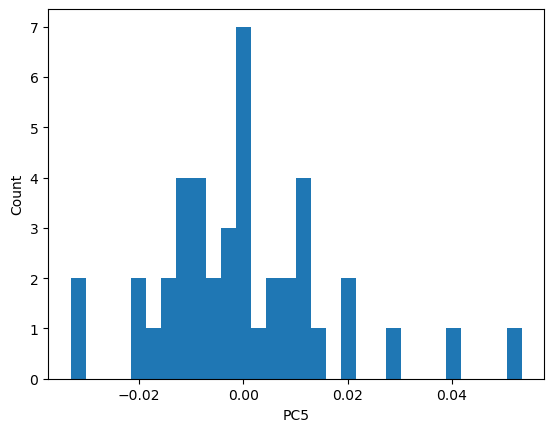

In [39]:
plt.hist(best_df["PC5"], bins=30)
plt.xlabel("PC5")
plt.ylabel("Count")
plt.show()

In [40]:
best_df.loc[best_df["PC5"].abs().idxmax()]

simulation                                            simulation000565
generation                                                         181
solution_index                                                      97
rank                                                                 0
source                                                      population
timestamp                                   2026-05-22T03:54:56.625221
mass                                                              70.0
a_val                                                              3.0
system_size                                                          5
alpha0                                                        5.869515
alpha1                                                       -0.622972
beta1                                                         -0.25458
alpha2                                                       -0.437381
beta2                                                          0.04949
fitnes

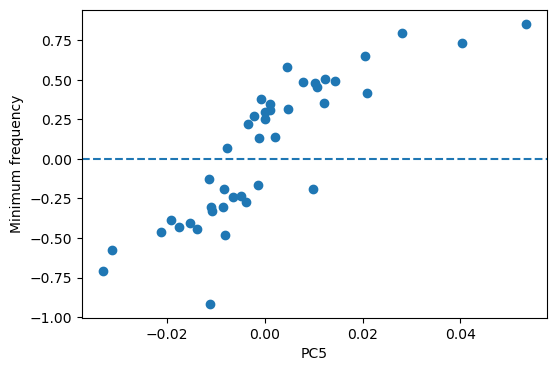

In [41]:
plt.figure(figsize=(6,4))

sc = plt.scatter(
    best_df["PC5"],
    best_df["min_frequency"],
)

plt.xlabel("PC5")
plt.ylabel("Minimum frequency")

plt.axhline(0, linestyle="--")

plt.show()

In [42]:
from scipy.stats import linregress

res = linregress(
    best_df["PC5"],
    best_df["min_frequency"],
)

print(res)

LinregressResult(slope=np.float64(22.582274148177653), intercept=np.float64(0.056016201006337245), rvalue=np.float64(0.8489374711483719), pvalue=np.float64(1.221733264411837e-12), stderr=np.float64(2.222805505953517), intercept_stderr=np.float64(0.036858078266754406))


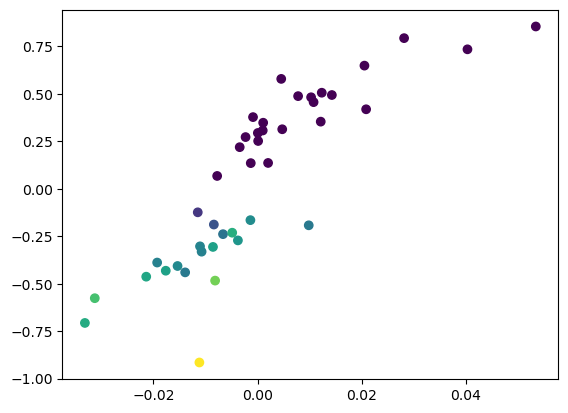

In [43]:
plt.scatter(
    best_df["PC5"],
    best_df["min_frequency"],
    c=best_df["num_imaginary"],
)

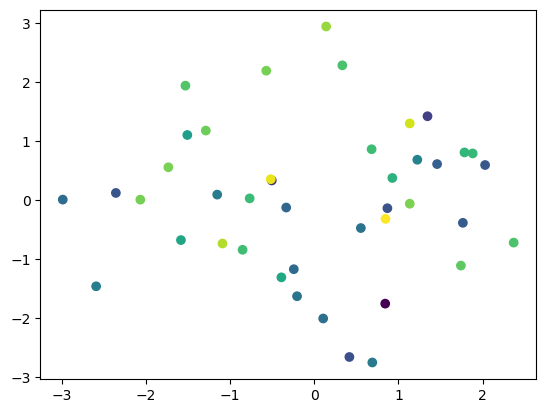

In [44]:
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=best_df["min_frequency"],
)

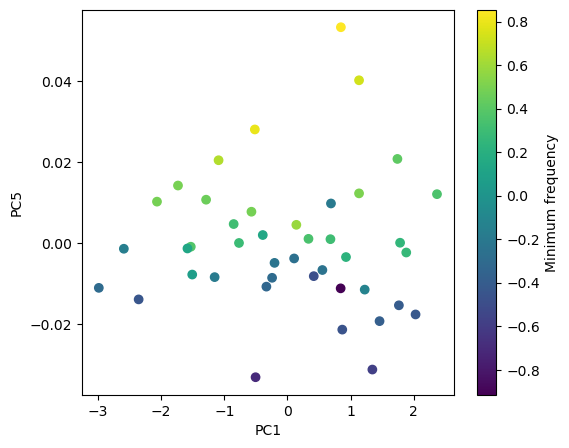

In [45]:
plt.figure(figsize=(6,5))

sc = plt.scatter(
    X_pca[:,0],
    best_df["PC5"],
    c=best_df["min_frequency"],
)

plt.xlabel("PC1")
plt.ylabel("PC5")

plt.colorbar(sc, label="Minimum frequency")

plt.show()

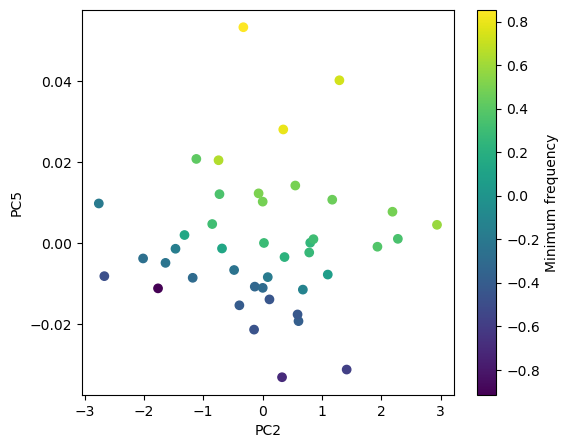

In [46]:
plt.figure(figsize=(6,5))

sc = plt.scatter(
    X_pca[:,1],
    best_df["PC5"],
    c=best_df["min_frequency"],
)

plt.xlabel("PC2")
plt.ylabel("PC5")

plt.colorbar(sc, label="Minimum frequency")

plt.show()

In [47]:
best_df["frequency_vector"] = best_df["frequencies"].apply(
    lambda x: x.reshape(-1)
)

In [48]:
X_freq = np.stack(best_df["frequency_vector"].values)

In [49]:
X_freq.shape

(42, 2412)

In [50]:
import umap

reducer = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    metric="euclidean",
    random_state=42,
)

X_umap = reducer.fit_transform(X_freq)

/Users/jamunoz/miniconda3/envs/moga/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


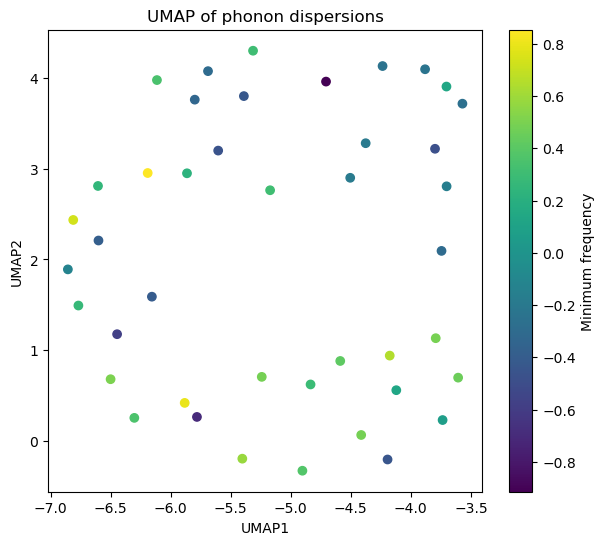

In [51]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=best_df["min_frequency"],
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.colorbar(sc, label="Minimum frequency")

plt.title("UMAP of phonon dispersions")

plt.show()

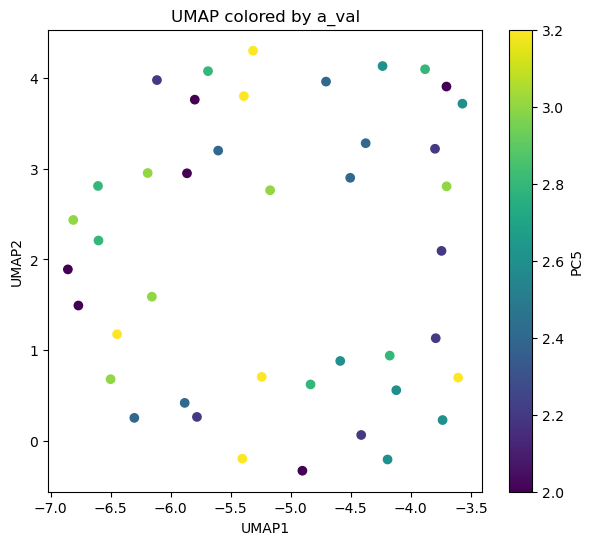

In [52]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=best_df["a_val"],
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.colorbar(sc, label="PC5")

plt.title("UMAP colored by a_val")

plt.show()

In [53]:
fc_cols = [
    "alpha0",
    "alpha1",
    "beta1",
    "alpha2",
    "beta2",
]

X_fc = best_df[fc_cols].values

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_fc_scaled = scaler.fit_transform(X_fc)

In [55]:
import umap

reducer_fc = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    metric="euclidean",
    random_state=42,
)

X_fc_umap = reducer_fc.fit_transform(X_fc_scaled)

/Users/jamunoz/miniconda3/envs/moga/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


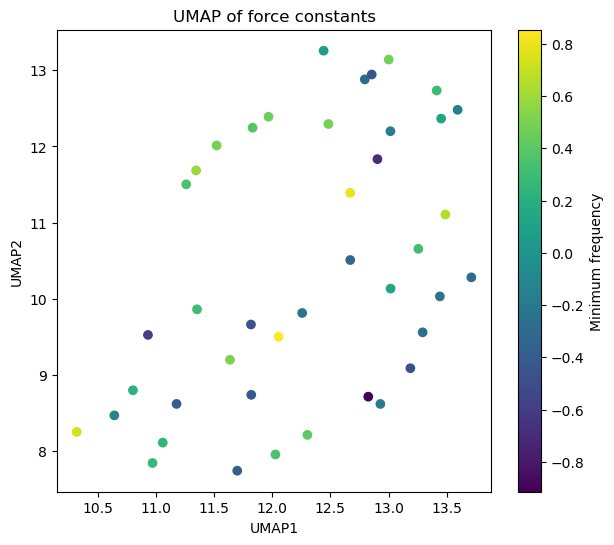

In [56]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    X_fc_umap[:,0],
    X_fc_umap[:,1],
    c=best_df["min_frequency"],
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.colorbar(sc, label="Minimum frequency")

plt.title("UMAP of force constants")

plt.show()

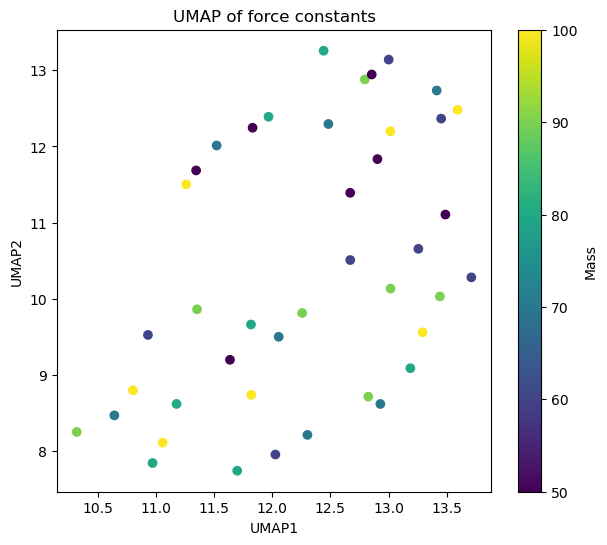

In [57]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    X_fc_umap[:,0],
    X_fc_umap[:,1],
    c=best_df["mass"],
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.colorbar(sc, label="Mass")

plt.title("UMAP of force constants")

plt.show()

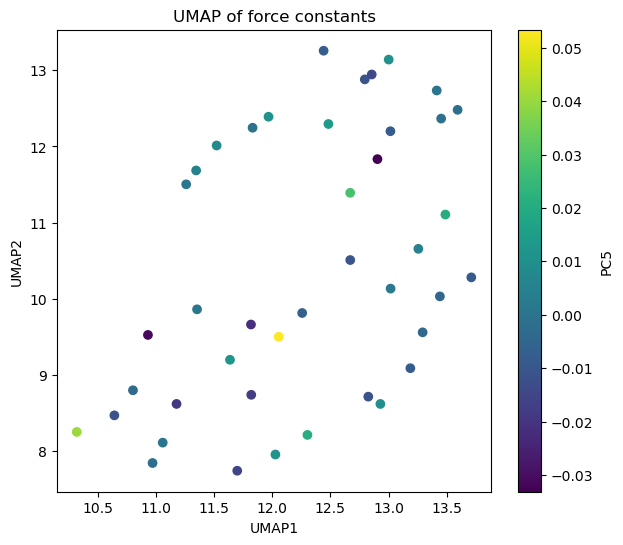

In [58]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    X_fc_umap[:,0],
    X_fc_umap[:,1],
    c=best_df["PC5"],
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.colorbar(sc, label="PC5")

plt.title("UMAP of force constants")

plt.show()

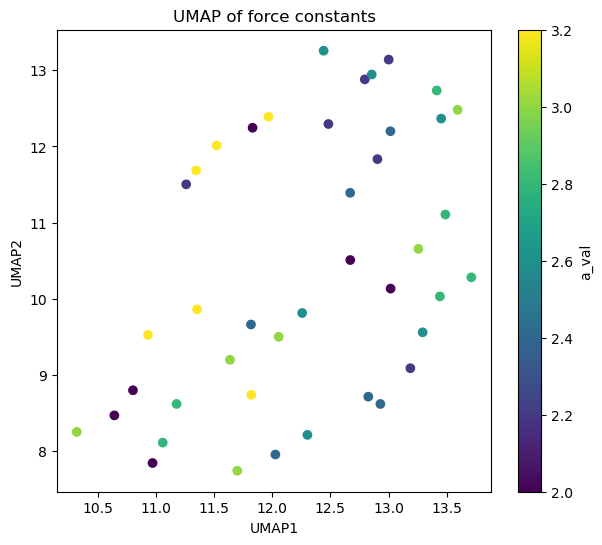

In [59]:
plt.figure(figsize=(7,6))

sc = plt.scatter(
    X_fc_umap[:,0],
    X_fc_umap[:,1],
    c=best_df["a_val"],
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")

plt.colorbar(sc, label="a_val")

plt.title("UMAP of force constants")

plt.show()

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.stats import pearsonr, spearmanr

In [61]:
fc_cols = ["alpha0", "alpha1", "beta1", "alpha2", "beta2"]

X_fc = best_df[fc_cols].to_numpy(dtype=np.float32)

X_ph = np.stack(
    best_df["frequencies"].apply(lambda x: x.reshape(-1)).values
).astype(np.float32)

In [62]:
X_fc_scaled = StandardScaler().fit_transform(X_fc)
X_ph_scaled = StandardScaler().fit_transform(X_ph)

In [63]:
D_fc = pairwise_distances(X_fc_scaled, metric="euclidean")
D_ph = pairwise_distances(X_ph_scaled, metric="euclidean")

In [64]:
iu = np.triu_indices_from(D_fc, k=1)

d_fc = D_fc[iu]
d_ph = D_ph[iu]

r_pearson = pearsonr(d_fc, d_ph)
r_spearman = spearmanr(d_fc, d_ph)

print("Pearson r:", r_pearson.statistic, "p =", r_pearson.pvalue)
print("Spearman rho:", r_spearman.statistic, "p =", r_spearman.pvalue)

Pearson r: 0.5007078 p = 7.875761251093413e-56
Spearman rho: 0.4958858583737344 p = 1.2386349358828508e-54


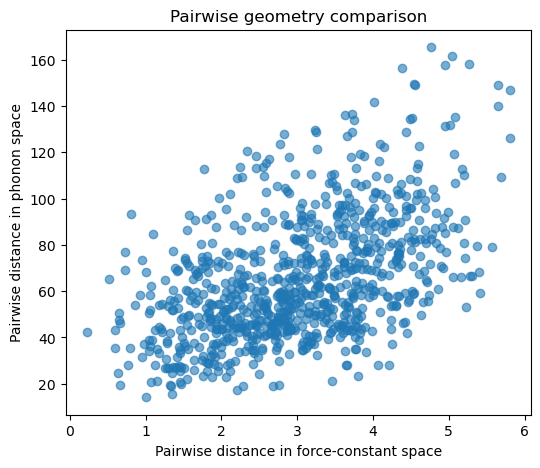

In [65]:
plt.figure(figsize=(6,5))

plt.scatter(d_fc, d_ph, alpha=0.6)

plt.xlabel("Pairwise distance in force-constant space")
plt.ylabel("Pairwise distance in phonon space")
plt.title("Pairwise geometry comparison")

plt.show()

In [66]:
def knn_indices(D, k):
    return np.argsort(D, axis=1)[:, 1:k+1]


def neighborhood_overlap(D1, D2, k):
    nn1 = knn_indices(D1, k)
    nn2 = knn_indices(D2, k)

    overlaps = []

    for a, b in zip(nn1, nn2):
        overlaps.append(
            len(set(a).intersection(set(b))) / k
        )

    return np.array(overlaps)

In [67]:
ks = [1, 2, 3, 5, 8, 10, 15, 20]

overlaps = []

for k in ks:
    ov = neighborhood_overlap(D_fc, D_ph, k)
    overlaps.append(ov.mean())

overlaps = np.array(overlaps)

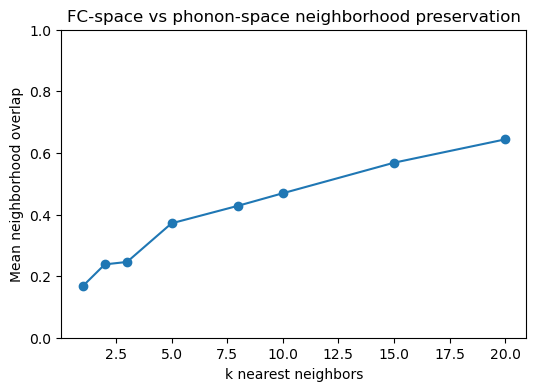

In [68]:
plt.figure(figsize=(6,4))

plt.plot(ks, overlaps, marker="o")

plt.xlabel("k nearest neighbors")
plt.ylabel("Mean neighborhood overlap")
plt.title("FC-space vs phonon-space neighborhood preservation")

plt.ylim(0, 1)

plt.show()

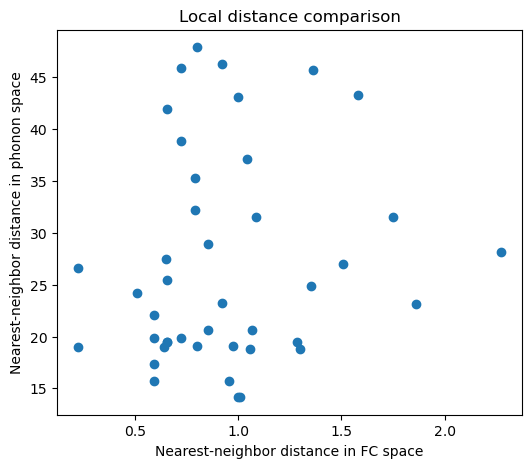

In [69]:
nearest_fc = np.min(D_fc + np.eye(len(D_fc))*1e9, axis=1)
nearest_ph = np.min(D_ph + np.eye(len(D_ph))*1e9, axis=1)

plt.figure(figsize=(6,5))

plt.scatter(nearest_fc, nearest_ph)

plt.xlabel("Nearest-neighbor distance in FC space")
plt.ylabel("Nearest-neighbor distance in phonon space")
plt.title("Local distance comparison")

plt.show()

In [70]:
pairs = pd.DataFrame({
    "i": iu[0],
    "j": iu[1],
    "d_fc": d_fc,
    "d_ph": d_ph,
})

pairs["folding_score"] = pairs["d_fc"] / (pairs["d_ph"] + 1e-8)

folded_pairs = pairs.sort_values("folding_score", ascending=False)

folded_pairs.head(10)

,i,j,d_fc,d_ph,folding_score
633,20,24,3.799585,23.117428,0.164360
784,29,31,3.452386,21.243795,0.162513
630,20,21,4.215563,28.034967,0.150368
648,20,39,4.065555,27.963104,0.145390
653,21,24,2.764053,19.453995,0.142081
50,1,11,2.679580,19.066767,0.140537
635,20,26,3.653236,28.061165,0.130188
80,1,41,3.640568,28.165197,0.129258
722,24,39,2.198610,17.338747,0.126803
817,32,34,2.280194,18.994999,0.120042


In [71]:
i, j = folded_pairs.iloc[0][["i", "j"]].astype(int)

best_df.iloc[[i, j]][
    [
        "simulation",
        "generation",
        "mass",
        "a_val",
        "alpha0",
        "alpha1",
        "beta1",
        "alpha2",
        "beta2",
        "fitness_norm",
        "min_frequency",
        "num_imaginary",
    ]
]

,simulation,generation,mass,a_val,alpha0,alpha1,beta1,alpha2,beta2,fitness_norm,min_frequency,num_imaginary
20,simulation000563,245,70.0,2.6,7.908264,-0.526107,0.218281,-1.849524,0.012441,1.685620,0.418235,0
24,simulation000550,74,50.0,2.8,5.496248,-0.340641,0.206031,0.042096,-0.692354,1.639122,0.648094,0


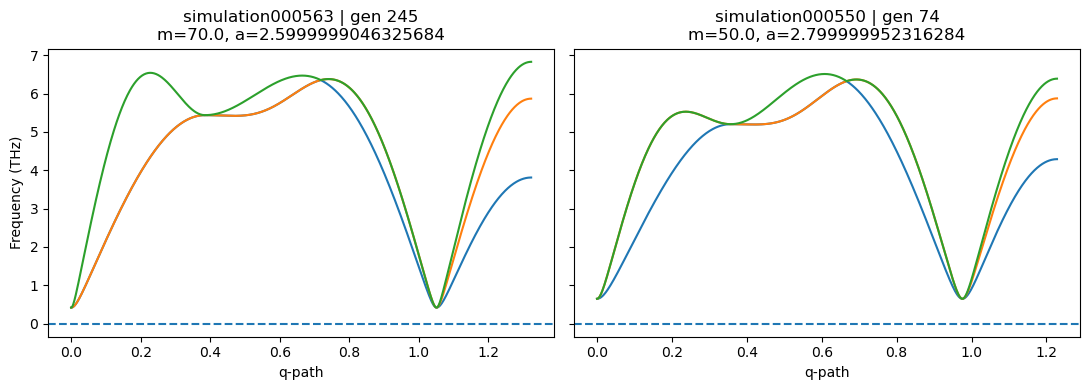

In [72]:
def plot_two_dispersions(row1, row2):
    fig, axes = plt.subplots(1, 2, figsize=(11,4), sharey=True)

    for ax, row in zip(axes, [row1, row2]):
        distances = row["distances"]
        freqs = row["frequencies"]

        for b in range(freqs.shape[1]):
            ax.plot(distances, freqs[:, b])

        ax.axhline(0, linestyle="--")
        ax.set_title(
            f"{row['simulation']} | gen {row['generation']}\n"
            f"m={row['mass']}, a={row['a_val']}"
        )
        ax.set_xlabel("q-path")

    axes[0].set_ylabel("Frequency (THz)")

    plt.tight_layout()
    plt.show()


plot_two_dispersions(best_df.iloc[i], best_df.iloc[j])

,alpha0,alpha1,beta1,alpha2,beta2
count,63000.000000,63000.000000,63000.000000,63000.000000,63000.000000
mean,7.241735,-0.510420,-0.009611,-0.552636,-0.478248
std,1.843442,0.283368,0.577826,0.692945,0.590415
min,1.075120,-1.649138,-1.986767,-1.999599,-1.991966
25%,6.087350,-0.706965,-0.410313,-1.139039,-0.909490
50%,7.634163,-0.535833,0.029422,-0.375674,-0.327206
75%,8.671979,-0.290080,0.411819,-0.021037,-0.021026
max,9.999774,0.822809,1.998299,1.997899,1.997978


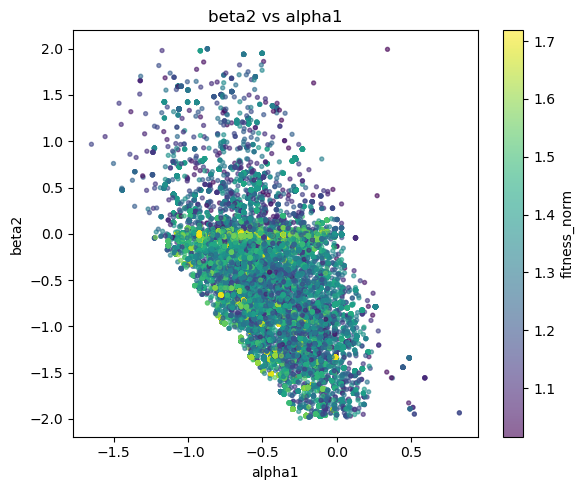

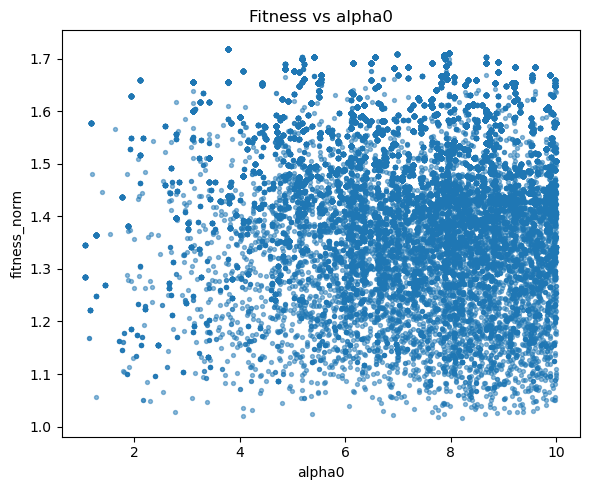

In [73]:
fc_cols = [c for c in ["alpha0", "alpha1", "beta1", "alpha2", "beta2"] if c in df.columns]
display(df[fc_cols].describe() if fc_cols else "No force-constant columns found.")

if len(fc_cols) >= 2:
    color_col = "fitness_norm" if "fitness_norm" in df.columns else None
    xcol, ycol = "alpha1", "beta2"
    if xcol in df.columns and ycol in df.columns:
        plt.figure(figsize=(6, 5))
        if color_col:
            sc = plt.scatter(df[xcol], df[ycol], c=df[color_col], s=8, alpha=0.6)
            plt.colorbar(sc, label=color_col)
        else:
            plt.scatter(df[xcol], df[ycol], s=8, alpha=0.6)
        plt.xlabel(xcol)
        plt.ylabel(ycol)
        plt.title(f"{ycol} vs {xcol}")
        plt.tight_layout()
        plt.show()

if "alpha0" in df.columns and "fitness_norm" in df.columns:
    plt.figure(figsize=(6, 5))
    plt.scatter(df["alpha0"], df["fitness_norm"], s=8, alpha=0.5)
    plt.xlabel("alpha0")
    plt.ylabel("fitness_norm")
    plt.title("Fitness vs alpha0")
    plt.tight_layout()
    plt.show()


,alpha0,alpha1,beta1,alpha2,beta2
count,63000.000000,63000.000000,63000.000000,63000.000000,63000.000000
mean,7.241735,-0.510420,-0.009611,-0.552636,-0.478248
std,1.843442,0.283368,0.577826,0.692945,0.590415
min,1.075120,-1.649138,-1.986767,-1.999599,-1.991966
25%,6.087350,-0.706965,-0.410313,-1.139039,-0.909490
50%,7.634163,-0.535833,0.029422,-0.375674,-0.327206
75%,8.671979,-0.290080,0.411819,-0.021037,-0.021026
max,9.999774,0.822809,1.998299,1.997899,1.997978


/var/folders/q4/9jxwyrx94pq6gsv5757mtyf80000gr/T/ipykernel_64591/1057657544.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


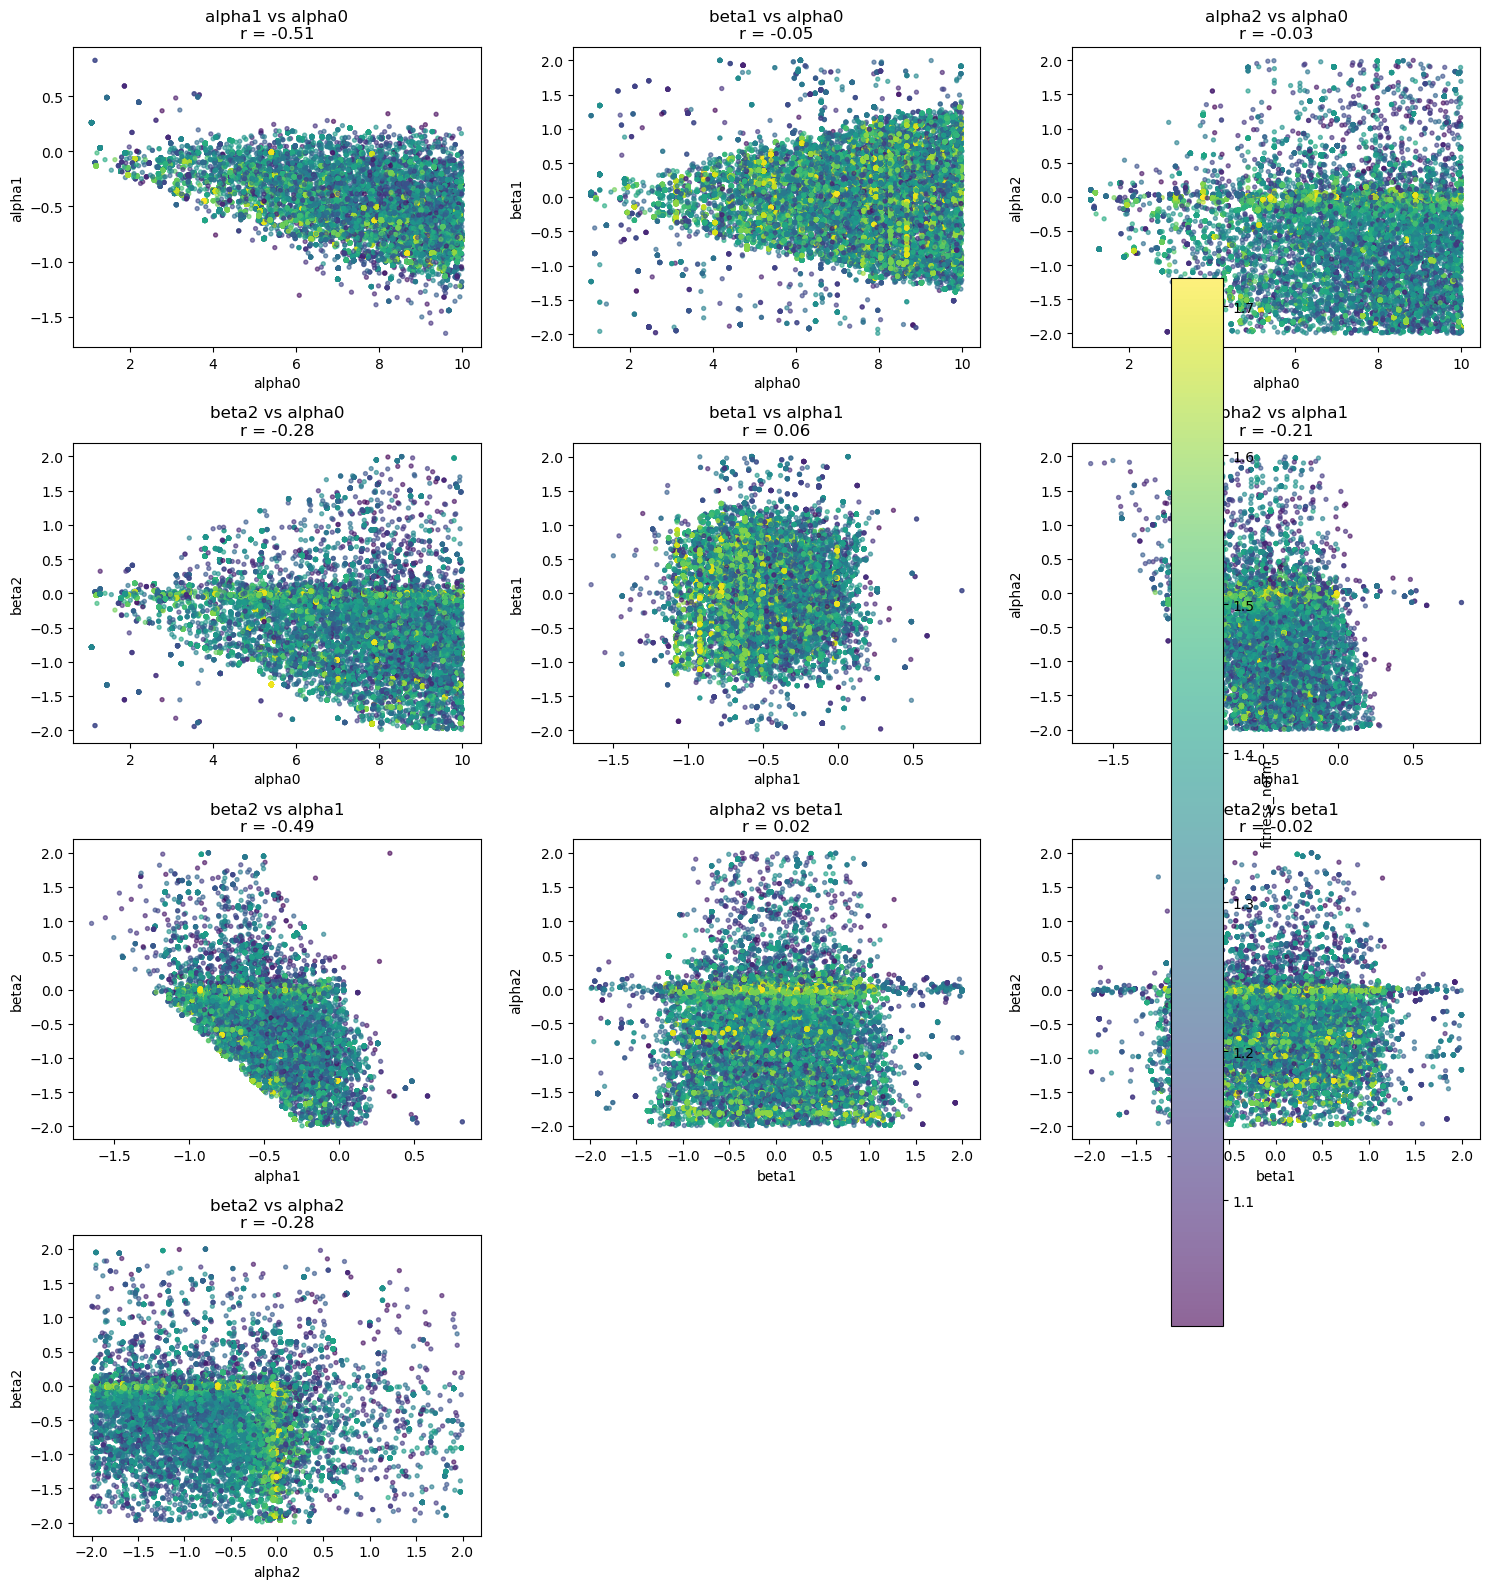

In [74]:
import itertools
import numpy as np
import matplotlib.pyplot as plt

fc_cols = [c for c in ["alpha0", "alpha1", "beta1", "alpha2", "beta2"] if c in df.columns]

display(df[fc_cols].describe() if fc_cols else "No force-constant columns found.")

color_col = "fitness_norm" if "fitness_norm" in df.columns else None

pairs = list(itertools.combinations(fc_cols, 2))

ncols = 3
nrows = int(np.ceil(len(pairs) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5*ncols, 4*nrows),
)

axes = np.ravel(axes)

for ax, (xcol, ycol) in zip(axes, pairs):

    if color_col:
        sc = ax.scatter(
            df[xcol],
            df[ycol],
            c=df[color_col],
            s=8,
            alpha=0.6,
        )
    else:
        ax.scatter(
            df[xcol],
            df[ycol],
            s=8,
            alpha=0.6,
        )

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)

    r = df[[xcol, ycol]].corr().iloc[0, 1]
    ax.set_title(f"{ycol} vs {xcol}\nr = {r:.2f}")

for ax in axes[len(pairs):]:
    ax.axis("off")

if color_col:
    cbar = fig.colorbar(sc, ax=axes.tolist(), shrink=0.85)
    cbar.set_label(color_col)

plt.tight_layout()
plt.show()